In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:86% !important;}
div.cell.code_cell.rendered{width:100%;}
div.CodeMirror {font-family:Consolas; font-size:12pt;}
div.output {font-size:15pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:12pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:5px;}
table.dataframe{font-size:15px;}
</style>
"""))

# 군집화

# 1. 데이터 생성
- 남자, 여자의 키와 몸무게 데이터를 군집화

In [2]:
import random
import numpy as np
import matplotlib.pyplot as plt

In [3]:
random.randint(40,95) # 40이상 95이하 정수 중 하나를 무작위 선택 반환

41

In [4]:
data = []
for i in range(50) :
    # 여자 데이터(몸무게, 키)
    data.append([random.randint(40,70), random.randint(140,170)])
    # 남자 데이터
    data.append([random.randint(60,95), random.randint(160,195)])
data

[[58, 168],
 [92, 164],
 [65, 163],
 [78, 179],
 [42, 149],
 [80, 161],
 [55, 165],
 [95, 190],
 [57, 141],
 [62, 166],
 [47, 167],
 [73, 182],
 [51, 158],
 [66, 175],
 [44, 167],
 [93, 178],
 [61, 146],
 [94, 178],
 [60, 155],
 [94, 185],
 [59, 149],
 [87, 169],
 [53, 140],
 [94, 169],
 [65, 160],
 [76, 172],
 [61, 156],
 [81, 162],
 [50, 170],
 [62, 190],
 [61, 163],
 [76, 168],
 [42, 166],
 [65, 184],
 [57, 143],
 [63, 171],
 [46, 168],
 [60, 188],
 [62, 162],
 [63, 188],
 [45, 165],
 [61, 160],
 [42, 169],
 [78, 165],
 [51, 161],
 [82, 161],
 [57, 169],
 [65, 176],
 [40, 159],
 [68, 167],
 [40, 144],
 [72, 166],
 [51, 166],
 [94, 194],
 [57, 147],
 [84, 172],
 [53, 167],
 [94, 183],
 [54, 141],
 [72, 193],
 [49, 141],
 [93, 182],
 [40, 160],
 [78, 183],
 [57, 150],
 [91, 160],
 [52, 146],
 [78, 172],
 [43, 145],
 [79, 171],
 [58, 157],
 [83, 184],
 [70, 163],
 [86, 161],
 [57, 148],
 [70, 168],
 [55, 140],
 [73, 179],
 [44, 161],
 [80, 178],
 [41, 140],
 [71, 166],
 [61, 166],
 [90

In [5]:
# 여자 데이터
for female in data[::2] :
    print(female, end=' ')
print('\n-----------------------------------------------------------------------------')
# 남자 데이터
for male in data[1::2] :
    print(male, end=' ')

[58, 168] [65, 163] [42, 149] [55, 165] [57, 141] [47, 167] [51, 158] [44, 167] [61, 146] [60, 155] [59, 149] [53, 140] [65, 160] [61, 156] [50, 170] [61, 163] [42, 166] [57, 143] [46, 168] [62, 162] [45, 165] [42, 169] [51, 161] [57, 169] [40, 159] [40, 144] [51, 166] [57, 147] [53, 167] [54, 141] [49, 141] [40, 160] [57, 150] [52, 146] [43, 145] [58, 157] [70, 163] [57, 148] [55, 140] [44, 161] [41, 140] [61, 166] [67, 140] [49, 157] [63, 170] [48, 166] [49, 149] [66, 162] [50, 140] [55, 159] 
-----------------------------------------------------------------------------
[92, 164] [78, 179] [80, 161] [95, 190] [62, 166] [73, 182] [66, 175] [93, 178] [94, 178] [94, 185] [87, 169] [94, 169] [76, 172] [81, 162] [62, 190] [76, 168] [65, 184] [63, 171] [60, 188] [63, 188] [61, 160] [78, 165] [82, 161] [65, 176] [68, 167] [72, 166] [94, 194] [84, 172] [94, 183] [72, 193] [93, 182] [78, 183] [91, 160] [78, 172] [79, 171] [83, 184] [86, 161] [70, 168] [73, 179] [80, 178] [71, 166] [90, 176] [

## 데이터 체크

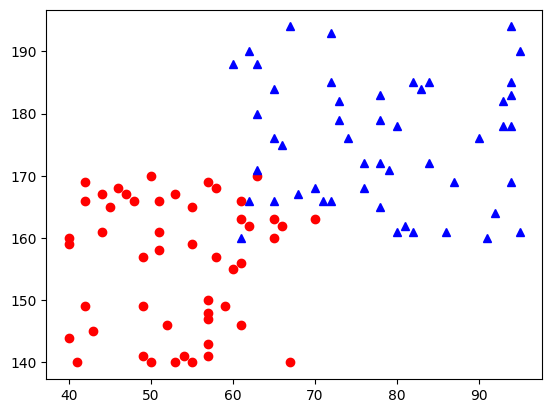

In [6]:
# print('여자 몸무게 :', [i[0] for i in data[::2]])
# print('\n ---------------------------------------')
# print('여자 키 :', [i[1] for i in data[::2]])
# print('\n ---------------------------------------')
# print('남자 몸무게 :', [i[0] for i in data[1::2]])
# print('\n ---------------------------------------')
# print('남자 키 :', [i[1] for i in data[1::2]])
# for d in data[::2] :
#     plt.plot(d[0],d[1],'o', color = 'r')
plt.plot([d[0] for d in data[::2]], [d[1] for d in data[::2]], 'o',color='r')
plt.plot([d[0] for d in data[1::2]], [d[1] for d in data[1::2]],'^', color='b')

# 2. 군집화 로직

In [7]:
# 초기 랜던 지점 2개
random_points = [[random.randint(40,95),random.randint(140,195)],
                [random.randint(40,95),random.randint(140,195)]]
random_points

[[95, 174], [95, 190]]

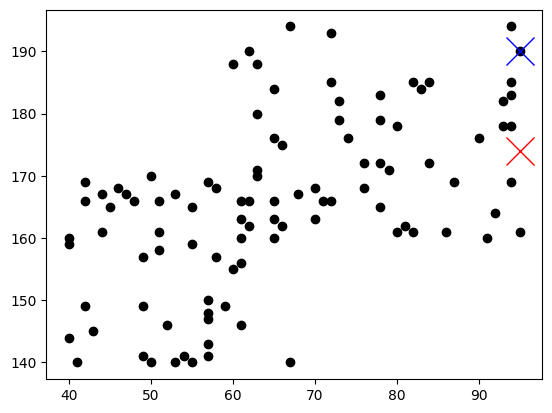

In [8]:
plt.plot([d[0] for d in data], [d[1] for d in data], 'o',color='k')
plt.plot(random_points[0][0], random_points[0][1], 'x', color = 'r', markersize=20) # 기준점 1
plt.plot(random_points[1][0], random_points[1][1], 'x', color = 'b', markersize=20) # 기준점 2

In [9]:
# 두 점의 거리를 return (0,0) ~ (4,3) 
def dist(a,b) :
    return np.sqrt(((a[0] - b[0])**2) + ((a[1] - b[1])**2))

In [10]:
a=[1,0] ; b=[4,3]
dist(a,b)

4.242640687119285

In [11]:
# 두 영역 random_points[0]과 random_points[1]을 기준으로 나눈 두 영역
group1 = [] # random_points[0]이 가까운 그룹
group2 = [] # random_points[1]이 가까운 그룹
for d in data :
    if dist(random_points[0],d) < dist(random_points[1],d) :
        group1.append(d) # random_points[0](기준점1)에 가까운 그룹
    else :
        group2.append(d) # random_points[1](기준점2)에 가까운 그룹
len(group1), len(group2)

(83, 17)

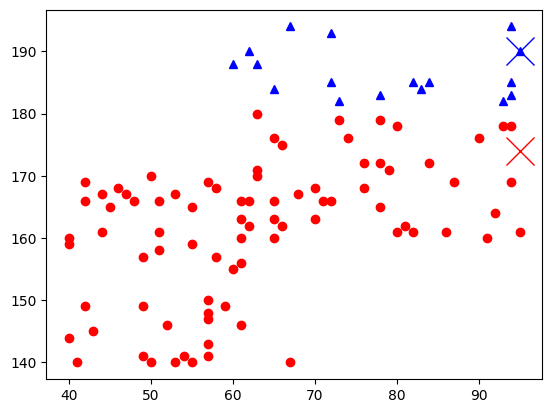

In [12]:
# 새로운 그룹 group1 과 group2, 초기 랜덤 지점
plt.plot([d[0] for d in group1],[d[1] for d in group1], 'o', color='r')
plt.plot([d[0] for d in group2],[d[1] for d in group2], '^', color='b')
plt.plot(random_points[0][0],random_points[0][1], 'x', color='r', markersize=20)
plt.plot(random_points[1][0],random_points[1][1], 'x', color='b', markersize=20)
plt.show()

In [13]:
# 기준점 이동 : group1의 중심점, group2의 중심점
X1 = sum([d[0] for d in group1])/len(group1)
Y1 = sum([d[1] for d in group1])/len(group1)
X2 = sum([d[0] for d in group2])/len(group2)
Y2 = sum([d[1] for d in group2])/len(group2)
random_points = [[X1,Y1],[X2,Y2]]

In [14]:
random_points # 기존 [[60, 145], [92, 149]] => 변화 후 [[55.67, 159.89],[84.03, 178.76]]

[[62.975903614457835, 161.40963855421685],
 [78.29411764705883, 186.76470588235293]]

# 3. 전체 코드(for문 이용)
- data 생성
- 랜덤포인트 2지점
- for문 시작
    - 랜덤포인트 2지점 기준으로 group화 => group1, group2
    - 랜덤포인트 이동(group1 중간점, group2 중간점)
- 데이터 점검

초기 point : [[94, 149], [79, 194]]
1번째 points : [[65.34, 155.16], [66.96, 178.2]]
2번째 points : [[58.824561403508774, 155.57894736842104], [75.86046511627907, 181.3953488372093]]
3번째 points : [[56.01851851851852, 155.57407407407408], [78.04347826086956, 179.7173913043478]]
4번째 points : [[54.98039215686274, 155.15686274509804], [77.77551020408163, 178.6734693877551]]
5번째 points : [[54.8, 154.86], [77.5, 178.5]]
6번째 points : [[54.8, 154.86], [77.5, 178.5]]
7번째 points : [[54.8, 154.86], [77.5, 178.5]]
8번째 points : [[54.8, 154.86], [77.5, 178.5]]
9번째 points : [[54.8, 154.86], [77.5, 178.5]]
10번째 points : [[54.8, 154.86], [77.5, 178.5]]


(140.0, 195.0)

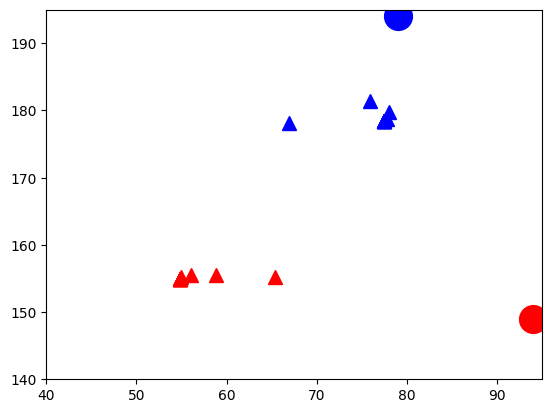

In [15]:
# 데이터 생성
data = []
for i in range(50) :
    # 여자 데이터(몸무게, 키)
    data.append([random.randint(40,70), random.randint(140,170)])
    # 남자 데이터
    data.append([random.randint(60,95), random.randint(160,195)])
# 랜던 포인트 2지점 지정
points = [[random.randint(40,95),random.randint(140,195)],
          [random.randint(40,95),random.randint(140,195)]]
print(f'초기 point : {points}')
plt.plot(points[0][0], points[0][1], 'o', color='r', markersize=20)
plt.plot(points[1][0], points[1][1], 'o', color='b', markersize=20)
# for문 시작
    # 랜덤포인트 2지점 기준으로 group화 => group1, group2

for i in range(10) :
    group1 = [] # points[0]과 가까운그룹
    group2 = [] # points[1]과 가까운 그룹
    for d in data :
        if dist(d, points[0]) < dist(d, points[1]) :
            group1.append(d)
        else :
            group2.append(d)
            
    # 새로운 포인트 할당
    sumX = 0; sumY = 0
    for g in group1 :
        sumX += g[0]
        sumY += g[1]
    points[0] = [sumX / len(group1), sumY / len(group1)]
    sumX = 0; sumY = 0
    for g in group2 :
        sumX += g[0]
        sumY += g[1]
    points[1] = [sumX / len(group2), sumY / len(group2)]
    print(f'{i+1}번째 points : {points}')
    plt.plot(points[0][0], points[0][1], '^', color='r', markersize=10)
    plt.plot(points[1][0], points[1][1], '^', color='b', markersize=10)
plt.xlim([40,95])
plt.ylim([140,195])

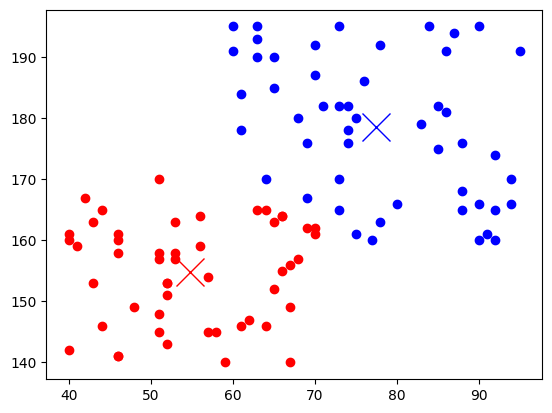

In [16]:
plt.plot([d[0] for d in group1],[d[1] for d in group1], 'o',color = 'r')
plt.plot([d[0] for d in group2],[d[1] for d in group2], 'o',color = 'b')
plt.plot(points[0][0],points[0][1],'x',color='r', markersize=20)
plt.plot(points[1][0],points[1][1],'x',color='b', markersize=20)

# 4. api(sklearn)를 이용한 군집화
- sklearn 머신러닝
    * 예측모델 
        ; 분류, 회귀, 군집 분석
        fit(학습), predict(예측)
    * 변환모델
        ; 전처리 ex. 스케일 조정
        fit(학습), transform(변환함수)

In [17]:
# 군집분석 라이브러리가 joblib 충돌 경고 메세지 출력. 아래와 같은 코드로 프로세스 병렬 진행(멀티쓰레드)을 막으면서 방지 가능
import os
os.environ['OMP_NUM_THREADS'] = "1"

In [18]:
data = np.array(data)
from sklearn.cluster import KMeans
model = KMeans(n_clusters=2, # 2개 그룹으로 나눠라
              init = 'random', # 초기 중심점 랜덤하게
              n_init = 10, # 10번 반복 실행
              random_state = 7)
model.fit(data)

KMeans(init='random', n_clusters=2, n_init=10, random_state=7)

In [19]:
# 중심점
model.cluster_centers_

array([[ 77.5 , 178.5 ],
       [ 54.8 , 154.86]])

In [20]:
# 중심점
model.cluster_centers_

array([[ 77.5 , 178.5 ],
       [ 54.8 , 154.86]])

In [21]:
groups1 = data[model.labels_ == 1]
groups2 = data[model.labels_ == 0]
c1, c2 = model.cluster_centers_

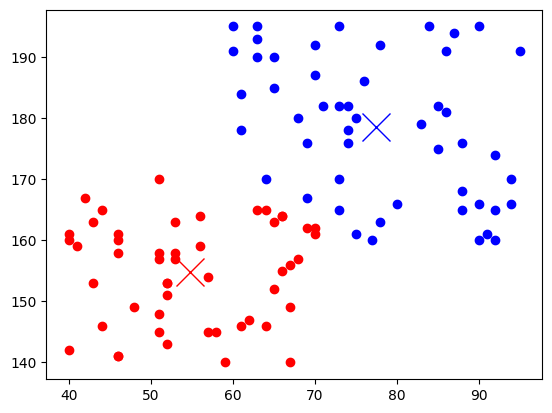

In [23]:
plt.plot([d[0] for d in group1],[d[1] for d in group1],'o',color = 'r')
plt.plot([d[0] for d in group2],[d[1] for d in group2],'o',color = 'b')
plt.plot(c1[0],c1[1], 'x', color='b', markersize=20)
plt.plot(c2[0],c2[1], 'x', color='r', markersize=20)